In [1]:
#neurokit permite simular señales sintéticas
#en eeg pueden probar y colocar spikes aleatorios
#6 ejercicios
#usar api de scipy

In [2]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 12.1 MB/s eta 0:00:00


In [7]:
import neurokit2 as nk
#Ejercicio 1
ecg1=nk.ecg_simulate(duration=10, length=None, sampling_rate=1000, noise=0.01, heart_rate=1200, heart_rate_std=1, method='ecgsyn', random_state=None)

In [8]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git
from signaldraw_isb import SignalDraw

ui = SignalDraw()
ui

  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-knm96a7m
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-knm96a7m
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 39.5 MB/s eta 0:00:00
  Created wheel for signaldraw-isb: filename=signaldraw_isb-0.1.0-py3-none-any.whl size=7729 sha256=3ef41898e99f96dc9c2d220a0bbd670ef7f235f45497347820676ba944915ca1
  Stored in directory: /tmp/pip-ephem-wheel-cache-53ryw4xa/wheels/a1/6a/b2/5fbb64642172e5c20aeab3e137b6f969bfed7f9c1dafde72b1
Successfully built signaldraw-isb


In [51]:
!pip install scipy
import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np
noise1=ui.signals[1]
noise2=ui.signals[2]
signal1=ecg1+noise1+noise2

#Filtrado
fir = signal.firwin(128,[15,30],
pass_zero=False,
fs=1000)
filtered = signal.lfilter(fir, 1.0, signal1)

# Ejercicio 1

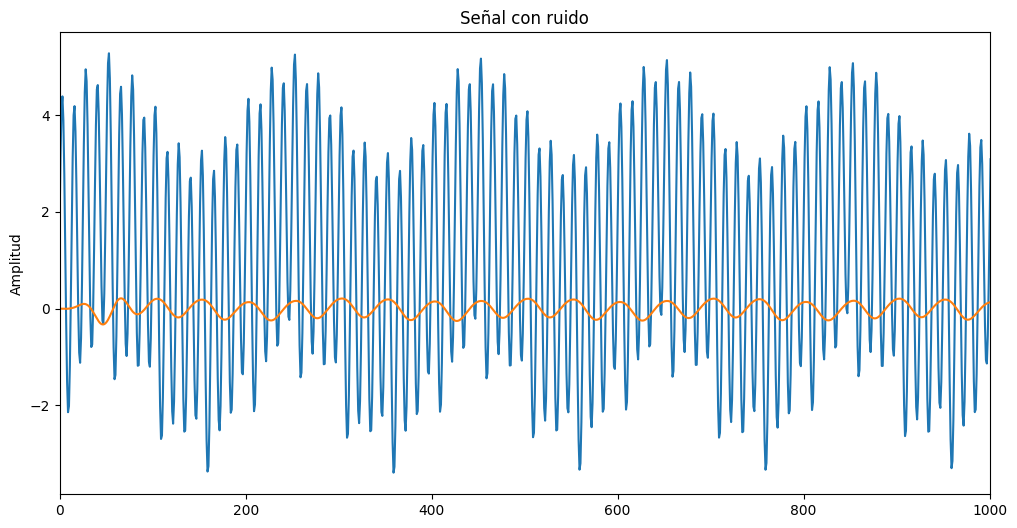

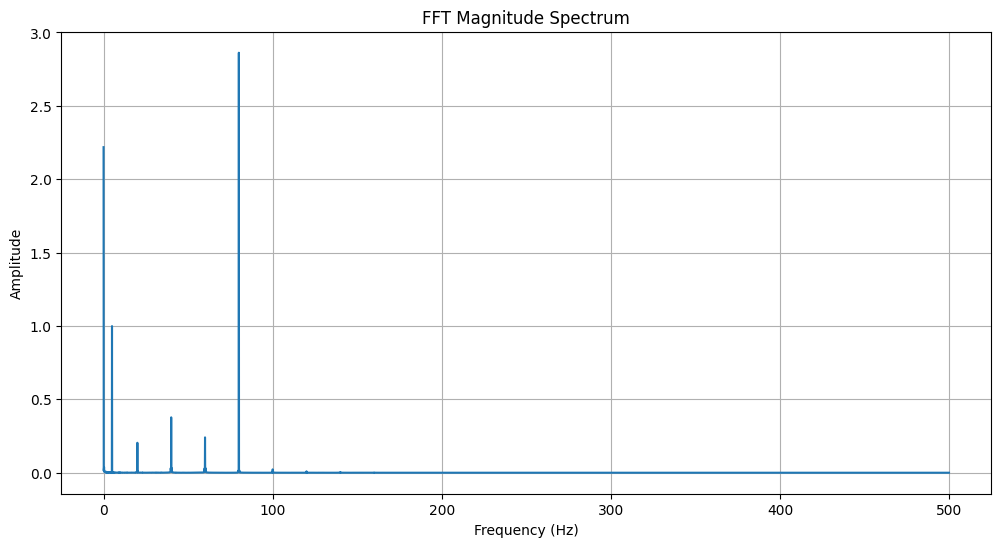

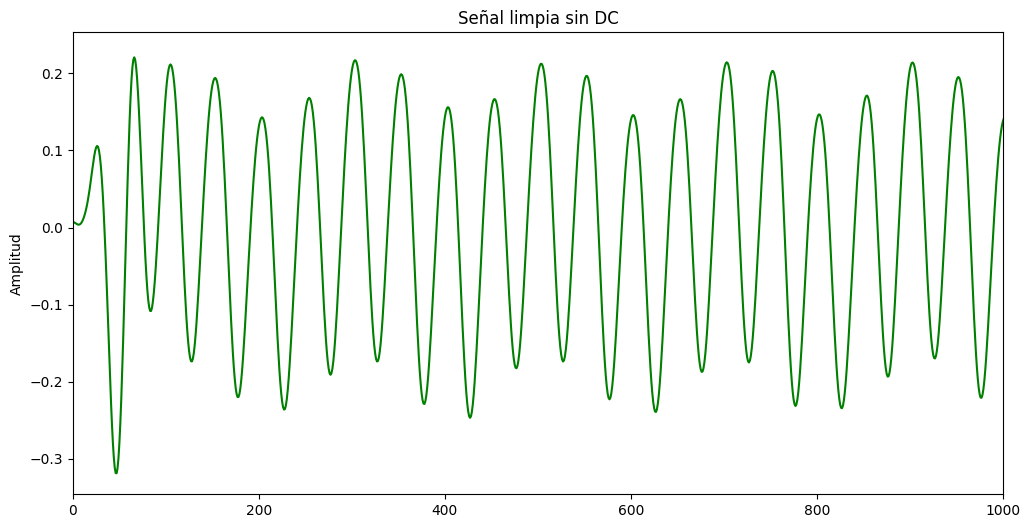

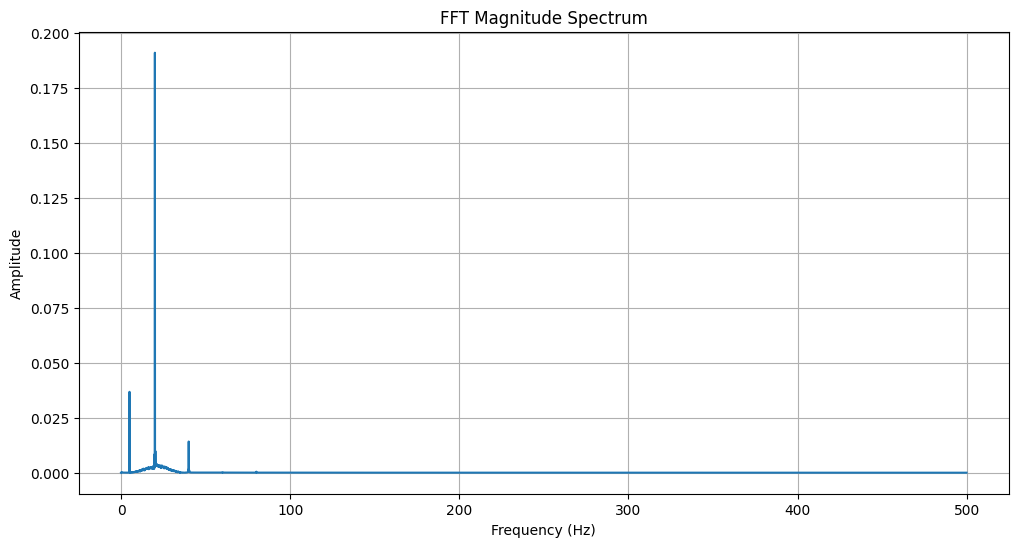

In [52]:
#SEÑAL ORIGINAL 1
n1=np.arange(len(signal1))

plt.figure(figsize=(12, 6))
plt.title('Señal con ruido')
plt.plot(n1,signal1)
plt.ylabel('Amplitud')
plt.xlim(0,1000)

plt.plot(n1,filtered)
plt.title('Señal con ruido')
plt.xlim(0,1000)

# 1. Setup
fs = 1000              # Sampling frequency (Hz)
t = np.arange(0, 10, 1/fs) # Tiempo


# 2. FFT
n = len(signal1)
yf = np.fft.fft(signal1)
xf = np.fft.fftfreq(n, 1/fs)

# 3. Visualizar
plt.figure(figsize=(12, 6))
plt.plot(xf[:n//2], 2.0/n * np.abs(yf[:n//2]))
plt.title('FFT Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

#SEÑAL LUEGO DEL FILTRADO 1
plt.figure(figsize=(12, 6))
filterednew=filtered-np.mean(filtered)
plt.ylabel('Amplitud')
plt.plot(n1,filterednew, color='green')
plt.title('Señal limpia sin DC')
plt.xlim(0,1000)

yf = np.fft.fft(filterednew)
xf = np.fft.fftfreq(n, 1/fs)

# 3. Visualization
# We only plot the positive frequencies (first half of the result)
plt.figure(figsize=(12, 6))
plt.plot(xf[:n//2], 2.0/n * np.abs(yf[:n//2]))
plt.title('FFT Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

# Ejercicio 2
ECG sintético, ruido blanco e interferencia de alta frecuencia

In [61]:
ecg2=nk.ecg_simulate(duration=10, length=None, sampling_rate=1000, noise=0.01, heart_rate=70, heart_rate_std=1, method='ecgsyn', random_state=None)
fs = 1000.0
tiempo = np.arange(0, 10, 1/fs)
ruido_blanco = np.random.normal(0, 1, len(tiempo))
ui2 = SignalDraw()
ui2

(0.0, 1000.0)

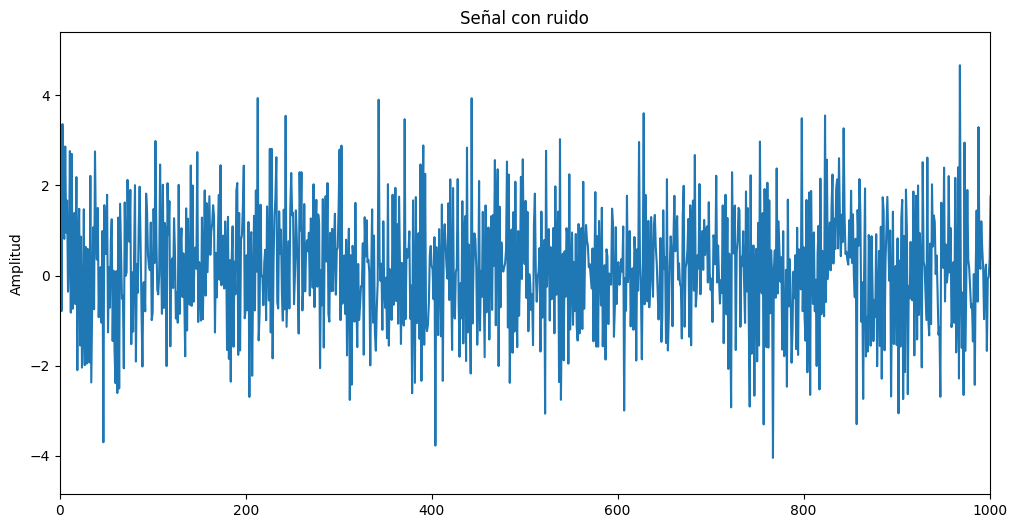

In [62]:
interferencia=ui2.signals[1]
signal2=ecg2+ruido_blanco+interferencia

n2=np.arange(len(signal2))

plt.figure(figsize=(12, 6))
plt.title('Señal con ruido')
plt.plot(n2,signal2)
plt.ylabel('Amplitud')
plt.xlim(0,1000)


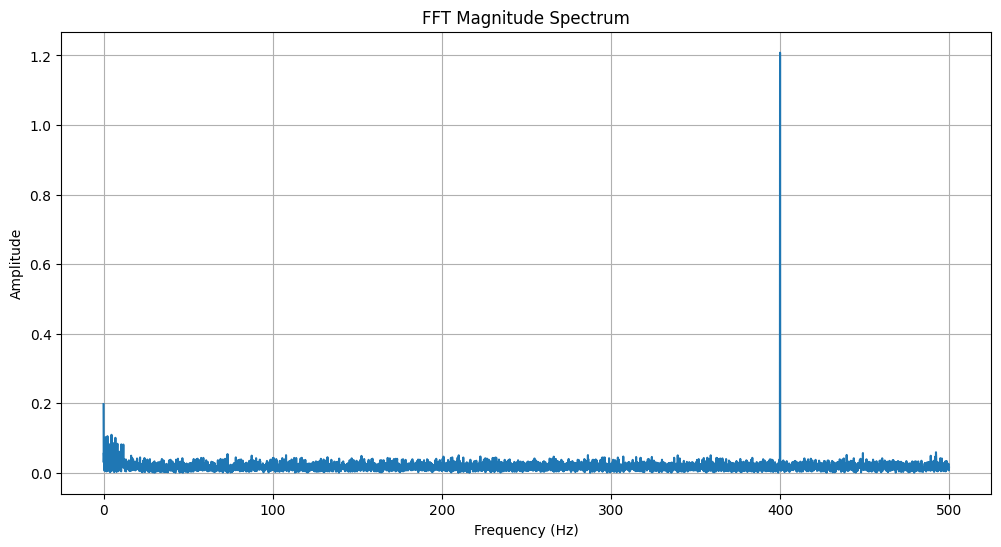

In [63]:

t = np.arange(0, 10, 1/fs) # Time vector (1 second)


# 2. FFT
n = len(signal2)
yf = np.fft.fft(signal2)
xf = np.fft.fftfreq(n, 1/fs)

# 3. Visualizar
plt.figure(figsize=(12, 6))
plt.plot(xf[:n//2], 2.0/n * np.abs(yf[:n//2]))
plt.title('FFT Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()
